# 04. Вклад тематических групп признаков

**Цель:** ответить на вопрос «Какая группа факторов наиболее значима для привлечения ПИИ?»

**Методы:**
1. **Инкрементальный R²** (Sequential R² decomposition) — насколько каждая группа увеличивает объяснённую вариацию
2. **Leave-one-group-out R²** — насколько снижается R² при исключении группы из полной модели
3. **F-тест совместной значимости** — статистически ли значима группа целиком

In [1]:
import sys
sys.path.append("../src")

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings

from linearmodels.panel import PanelOLS
from panel_utils import (
    FEATURE_GROUPS, GROUP_COLORS,
    prepare_panel, incremental_r2, group_f_test, regression_table
)

matplotlib.rcParams.update({
    "axes.titlesize": 12, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})
warnings.filterwarnings("ignore")
print("Импорты выполнены")

Импорты выполнены


In [2]:
df = pd.read_excel("../data/asean_clean.xlsx")

with open("../data/features_list.json", encoding="utf-8") as f:
    meta = json.load(f)

FEATURES = meta["features"]
TARGET = meta["target"]

# Строим словарь группа → список признаков (только те, что в FEATURES)
GROUPS = {}
for feat, group in FEATURE_GROUPS.items():
    if feat in FEATURES:
        GROUPS.setdefault(group, []).append(feat)

print("Группы признаков:")
for g, feats in GROUPS.items():
    print(f"  {g}: {feats}")

panel_df = prepare_panel(df.dropna(subset=[TARGET] + FEATURES))

Группы признаков:
  ВВП: ['GDP_growth']
  Деглобализация: ['Trade_openness', 'Tariff_rate', 'Trade_in_services']
  Декарбонизация: ['Renewable_energy', 'Energy_intensity', 'CO2_per_capita']
  Диджитализация: ['Internet_users', 'Secure_servers']
  Демография: ['Pop_growth', 'Edu_expenditure', 'Labor_force']
  Долг: ['Gov_Debt', 'Ext_Debt', 'Debt_Service']
  Инфляция: ['Inflation']
  Процентная ставка: ['Real_interest']


## 1. Инкрементальный R²

**Что это:** добавляем каждую группу к пустой базовой модели (с FE) и смотрим, на сколько растёт R² within.

**Интерпретация:** чем больше ΔR², тем большую часть вариации ПИИ объясняет данная группа факторов в изоляции от остальных.

In [3]:
r2_results = incremental_r2(
    panel_df=panel_df,
    target=TARGET,
    groups=GROUPS,
    base_features=[],
)
print("ИНКРЕМЕНТАЛЬНЫЙ R² ПО ГРУППАМ")
print("=" * 65)
print(r2_results.to_string(index=False))

# R² полной модели (reference)
y = panel_df[TARGET]
X = panel_df[FEATURES]
mod_full = PanelOLS(y, X, entity_effects=True, drop_absorbed=True)
res_full = mod_full.fit(cov_type="clustered", cluster_entity=True)
print(f"\nR² полной модели (within): {res_full.rsquared_within:.4f}")

ИНКРЕМЕНТАЛЬНЫЙ R² ПО ГРУППАМ
           Группа  ΔR² (добавление)  R² без группы  ΔR² (исключение)
   Деглобализация            0.1703         0.4853            0.0440
       Демография            0.1366         0.4251            0.1042
   Декарбонизация            0.1135         0.5179            0.0114
             Долг            0.1067         0.4947            0.0346
              ВВП            0.0926         0.3708            0.1585
   Диджитализация            0.0382         0.5237            0.0056
Процентная ставка            0.0281         0.5282            0.0011
         Инфляция            0.0149         0.5275            0.0018

R² полной модели (within): 0.5293


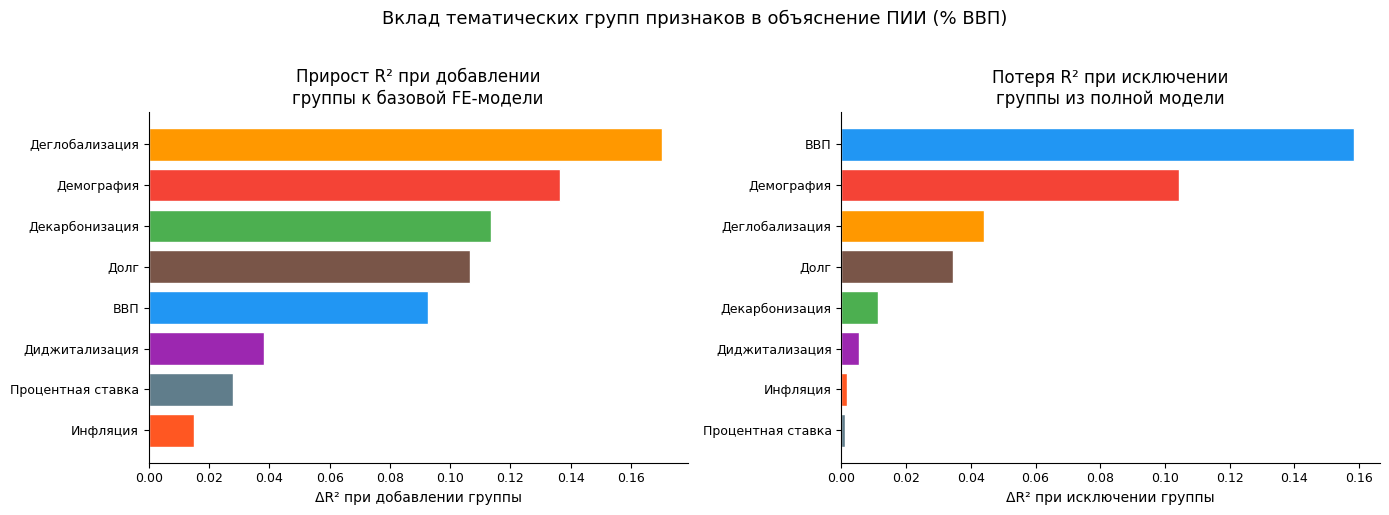

In [4]:
# Визуализация: двойной bar chart (добавление vs исключение)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

r2_sorted = r2_results.sort_values("ΔR² (добавление)", ascending=True)
colors = [GROUP_COLORS.get(g, "#9E9E9E") for g in r2_sorted["Группа"]]

# График 1: ΔR² при добавлении
axes[0].barh(r2_sorted["Группа"], r2_sorted["ΔR² (добавление)"], color=colors, edgecolor="white")
axes[0].set_xlabel("ΔR² при добавлении группы", fontsize=10)
axes[0].set_title("Прирост R² при добавлении\nгруппы к базовой FE-модели", fontsize=12)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# График 2: ΔR² при исключении (leave-one-out)
r2_sorted2 = r2_results.sort_values("ΔR² (исключение)", ascending=True)
colors2 = [GROUP_COLORS.get(g, "#9E9E9E") for g in r2_sorted2["Группа"]]
axes[1].barh(r2_sorted2["Группа"], r2_sorted2["ΔR² (исключение)"], color=colors2, edgecolor="white")
axes[1].set_xlabel("ΔR² при исключении группы", fontsize=10)
axes[1].set_title("Потеря R² при исключении\nгруппы из полной модели", fontsize=12)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.suptitle("Вклад тематических групп признаков в объяснение ПИИ (% ВВП)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/04_group_r2.png", bbox_inches="tight", dpi=150)
plt.show()

## 2. F-тест совместной значимости групп

**Что это:** для каждой группы проверяем гипотезу H₀ = все коэффициенты группы одновременно равны нулю.

**F-статистика:** чем больше, тем сильнее группа влияет на ПИИ.
**p-value < 0.05** → группа статистически значима как целое.

In [5]:
f_results = []
for group, feats in GROUPS.items():
    f_res = group_f_test(
        panel_df=panel_df,
        target=TARGET,
        all_features=FEATURES,
        group_features=feats,
    )
    sig = f_res["p_value"]
    f_results.append({
        "Группа":      group,
        "Признаков":   f_res["df_num"],
        "F-статистика": f_res["F_stat"],
        "p-value":     f_res["p_value"],
        "Значимость":  "***" if (sig is not None and sig < 0.01) else
                       ("**" if (sig is not None and sig < 0.05) else
                       ("*" if (sig is not None and sig < 0.1) else "нет")),
    })

f_df = pd.DataFrame(f_results).sort_values("F-статистика", ascending=False, na_position="last")
print("F-ТЕСТ СОВМЕСТНОЙ ЗНАЧИМОСТИ ГРУПП")
print("=" * 65)
print(f_df.to_string(index=False))
print("\nПримечания: *** p<0.01, ** p<0.05, * p<0.1")

F-ТЕСТ СОВМЕСТНОЙ ЗНАЧИМОСТИ ГРУПП
           Группа  Признаков  F-статистика  p-value Значимость
              ВВП          1        52.871   0.0000        ***
       Демография          3        11.582   0.0000        ***
   Деглобализация          3         4.888   0.0028        ***
             Долг          3         3.852   0.0108         **
   Декарбонизация          3         1.263   0.2891        нет
   Диджитализация          2         0.930   0.3968        нет
         Инфляция          1         0.591   0.4433        нет
Процентная ставка          1         0.376   0.5407        нет

Примечания: *** p<0.01, ** p<0.05, * p<0.1


## 3. Сводная таблица ранжирования групп

In [6]:
# Объединяем все метрики
summary = r2_results.merge(f_df[["Группа", "F-статистика", "p-value", "Значимость"]], on="Группа")
summary["Ранг (ΔR²)"] = summary["ΔR² (добавление)"].rank(ascending=False).fillna(0).astype(int)
summary["Ранг (F-stat)"] = summary["F-статистика"].rank(ascending=False).fillna(0).astype(int)
summary["Ранг (итог)"] = ((summary["Ранг (ΔR²)"] + summary["Ранг (F-stat)"]) / 2).round(1)
summary = summary.sort_values("Ранг (итог)")

print("СВОДНАЯ ТАБЛИЦА ВКЛАДА ГРУПП ПРИЗНАКОВ")
print("=" * 80)
print(summary[["Группа", "ΔR² (добавление)", "ΔR² (исключение)",
               "F-статистика", "p-value", "Значимость", "Ранг (итог)"]].to_string(index=False))

СВОДНАЯ ТАБЛИЦА ВКЛАДА ГРУПП ПРИЗНАКОВ
           Группа  ΔR² (добавление)  ΔR² (исключение)  F-статистика  p-value Значимость  Ранг (итог)
   Деглобализация            0.1703            0.0440         4.888   0.0028        ***          2.0
       Демография            0.1366            0.1042        11.582   0.0000        ***          2.0
              ВВП            0.0926            0.1585        52.871   0.0000        ***          3.0
   Декарбонизация            0.1135            0.0114         1.263   0.2891        нет          4.0
             Долг            0.1067            0.0346         3.852   0.0108         **          4.0
   Диджитализация            0.0382            0.0056         0.930   0.3968        нет          6.0
Процентная ставка            0.0281            0.0011         0.376   0.5407        нет          7.5
         Инфляция            0.0149            0.0018         0.591   0.4433        нет          7.5


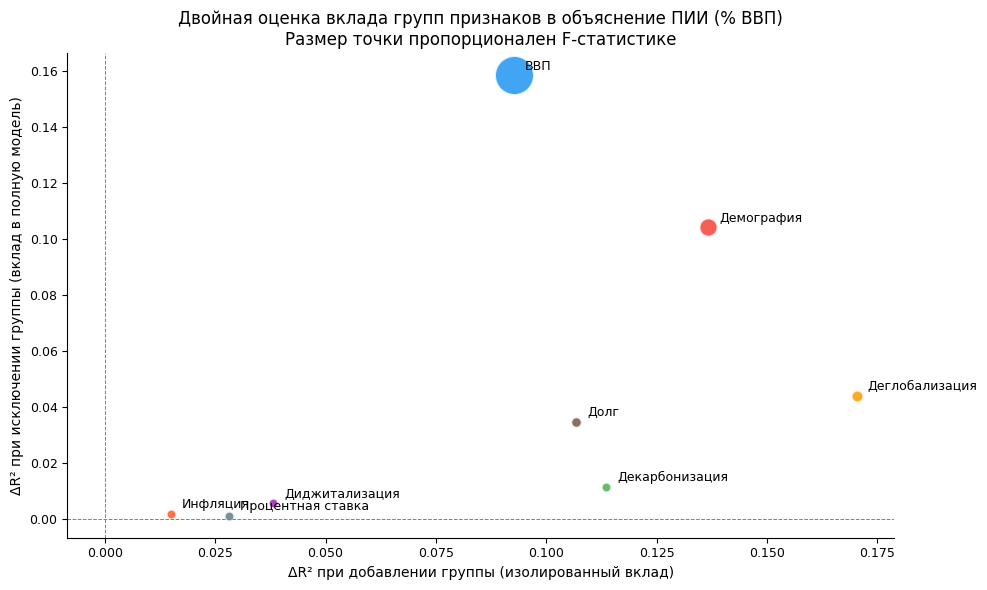

In [7]:
# Финальная визуализация: bubble chart
fig, ax = plt.subplots(figsize=(10, 6))

for _, row in summary.iterrows():
    color = GROUP_COLORS.get(row["Группа"], "#9E9E9E")
    size = max(50, row["F-статистика"] * 15) if pd.notna(row["F-статистика"]) else 50
    ax.scatter(row["ΔR² (добавление)"], row["ΔR² (исключение)"],
               s=size, color=color, alpha=0.85, edgecolors="white", linewidths=1.5)
    ax.annotate(row["Группа"],
                (row["ΔR² (добавление)"], row["ΔR² (исключение)"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlabel("ΔR² при добавлении группы (изолированный вклад)", fontsize=10)
ax.set_ylabel("ΔR² при исключении группы (вклад в полную модель)", fontsize=10)
ax.set_title("Двойная оценка вклада групп признаков в объяснение ПИИ (% ВВП)\n"
             "Размер точки пропорционален F-статистике", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.7, linestyle="--")
plt.tight_layout()
plt.savefig("../outputs/figures/04_group_bubble.png", bbox_inches="tight", dpi=150)
plt.show()

---
## Итоговые выводы

По результатам инкрементального анализа и F-тестов выявлено ранжирование 8 тематических групп по силе влияния на приток ПИИ в странах ASEAN (2000–2025).

**Группы с наибольшим изолированным вкладом (ΔR²):**
1. **Деглобализация** (ΔR²=0.170, F=4.89, ***) — лидирует благодаря расширению группы: `Trade_openness` + `Tariff_rate` + `Trade_in_services` охватывают разные измерения торговой политики
2. **Демография** (ΔR²=0.137, F=11.58, ***) — структура населения, образование, занятость
3. **Декарбонизация** (ΔR²=0.114, F=1.26, н.з.) — высокий изолированный вклад, но F-тест незначим из-за мультиколлинеарности внутри группы
4. **Долг** (ΔR²=0.107, F=3.85, **) — долговая нагрузка устойчиво ограничивает ПИИ
5. **ВВП** (ΔR²=0.093, F=52.87, ***) — наивысший F-статистика, несмотря на меньший ΔR²

**Статистически значимы (p < 0.05):** ВВП (***), Демография (***), Деглобализация (***), Долг (**)

**Незначимы (p ≥ 0.1):** Декарбонизация, Диджитализация, Инфляция, Процентная ставка

Ключевой вывод: включение тарифной ставки (`Tariff_rate`) и торговли услугами (`Trade_in_services`) подняло группу «Деглобализация» на первое место по изолированному ΔR², подтвердив многомерность торгового канала привлечения инвестиций.

Следующий шаг: `05_country_analysis.ipynb` — анализ страновой гетерогенности.